# Cross-dataset analysis

Цель этапа - объединить результаты Adult Census и Breast Cancer, сравнить влияние preprocessing и сделать итоговый исследовательский вывод.

In [1]:
from pathlib import Path
import sys
import warnings

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / "src"))
RESULTS_DIR = PROJECT_ROOT / "results"
FIGURES_DIR = PROJECT_ROOT / "figures"
RESULTS_DIR.mkdir(exist_ok=True)
FIGURES_DIR.mkdir(exist_ok=True)

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from experiment_utils import save_figure, save_results

sns.set_theme(style="whitegrid")


## Загрузка CSV-результатов

In [2]:
adult_baseline = pd.read_csv(RESULTS_DIR / "baseline_results.csv")
adult_scaling = pd.read_csv(RESULTS_DIR / "scaling_results.csv")
adult_imputation = pd.read_csv(RESULTS_DIR / "imputation_results.csv")
adult_balancing = pd.read_csv(RESULTS_DIR / "balancing_results.csv")
adult_models = pd.read_csv(RESULTS_DIR / "models_comparison_results.csv")

bc_baseline = pd.read_csv(RESULTS_DIR / "breast_cancer_baseline_results.csv")
bc_scaling = pd.read_csv(RESULTS_DIR / "breast_cancer_scaling_results.csv")
bc_imputation = pd.read_csv(RESULTS_DIR / "breast_cancer_imputation_results.csv")
bc_models = pd.read_csv(RESULTS_DIR / "breast_cancer_models_comparison_results.csv")

all_results = pd.concat([
    adult_baseline, adult_scaling, adult_imputation, adult_balancing, adult_models,
    bc_baseline, bc_scaling, bc_imputation, bc_models,
], ignore_index=True, sort=False)
all_results = all_results.round(4)
save_results(all_results, RESULTS_DIR / "cross_dataset_summary.csv")
all_results.head()


,Dataset,Experiment,Model,Accuracy,F1-score,ROC-AUC,Preprocessing,Balancing
0,Adult,Baseline,LogisticRegression,0.8520,0.6539,0.9012,NaN,NaN
1,Adult,Scaling,LogisticRegression,0.8520,0.6539,0.9012,No scaling,NaN
2,Adult,Scaling,LogisticRegression,0.8525,0.6568,0.9040,StandardScaler,NaN
3,Adult,Scaling,LogisticRegression,0.8525,0.6547,0.9021,MinMaxScaler,NaN
4,Adult,Imputation,LogisticRegression,0.8525,0.6568,0.9040,SimpleImputer median/mode,NaN


## Лучшие F1-score и ROC-AUC по датасетам

In [3]:
best_f1 = all_results.loc[all_results.groupby("Dataset")["F1-score"].idxmax()].copy()
best_roc_auc = all_results.loc[all_results.groupby("Dataset")["ROC-AUC"].idxmax()].copy()
best_f1[["Dataset", "Experiment", "Model", "F1-score"]], best_roc_auc[["Dataset", "Experiment", "Model", "ROC-AUC"]]


(          Dataset Experiment               Model  F1-score
 8           Adult  Balancing  LogisticRegression    0.6762
 15  Breast Cancer    Scaling  LogisticRegression    0.9639,
           Dataset Experiment               Model  ROC-AUC
 7           Adult  Balancing  LogisticRegression   0.9042
 16  Breast Cancer    Scaling  LogisticRegression   0.9997)

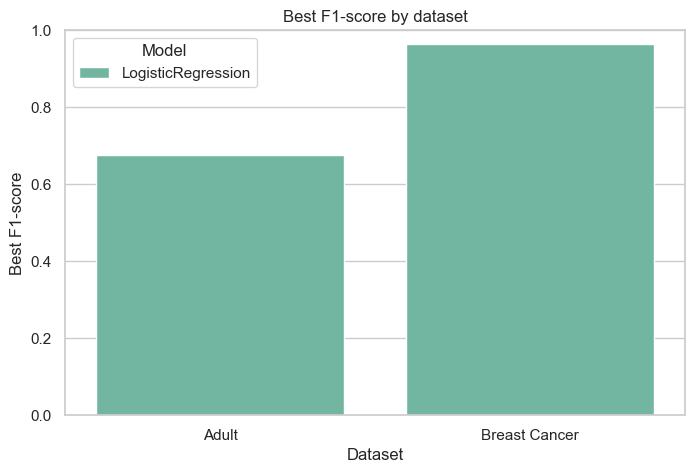

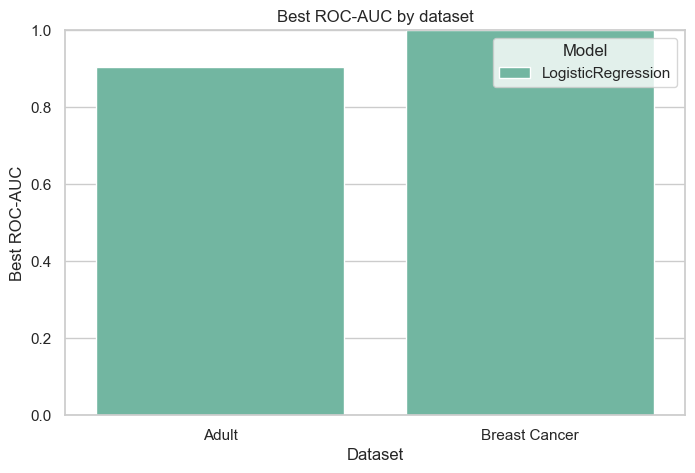

In [4]:
plt.figure(figsize=(8, 5))
sns.barplot(data=best_f1, x="Dataset", y="F1-score", hue="Model", palette="Set2")
plt.ylim(0, 1.0)
plt.title("Best F1-score by dataset")
plt.xlabel("Dataset")
plt.ylabel("Best F1-score")
save_figure(FIGURES_DIR / "cross_dataset_best_f1.png")
plt.show()

plt.figure(figsize=(8, 5))
sns.barplot(data=best_roc_auc, x="Dataset", y="ROC-AUC", hue="Model", palette="Set2")
plt.ylim(0, 1.0)
plt.title("Best ROC-AUC by dataset")
plt.xlabel("Dataset")
plt.ylabel("Best ROC-AUC")
save_figure(FIGURES_DIR / "cross_dataset_best_roc_auc.png")
plt.show()


## Влияние scaling

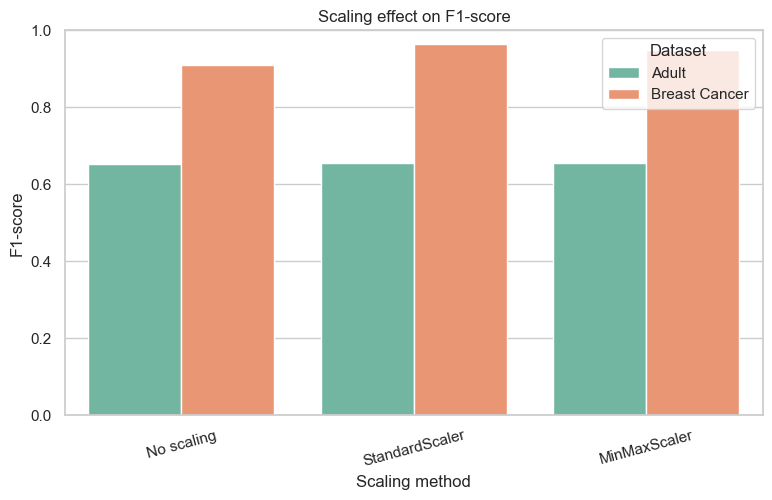

,Dataset,Experiment,Model,Preprocessing,Accuracy,F1-score,ROC-AUC
0,Adult,Scaling,LogisticRegression,No scaling,0.8520,0.6539,0.9012
1,Adult,Scaling,LogisticRegression,StandardScaler,0.8525,0.6568,0.9040
2,Adult,Scaling,LogisticRegression,MinMaxScaler,0.8525,0.6547,0.9021
3,Breast Cancer,Scaling,LogisticRegression,No scaling,0.9386,0.9114,0.9937
4,Breast Cancer,Scaling,LogisticRegression,StandardScaler,0.9737,0.9639,0.9960
5,Breast Cancer,Scaling,LogisticRegression,MinMaxScaler,0.9649,0.9500,0.9997


In [5]:
scaling_results = pd.concat([adult_scaling, bc_scaling], ignore_index=True)
plt.figure(figsize=(9, 5))
sns.barplot(data=scaling_results, x="Preprocessing", y="F1-score", hue="Dataset", palette="Set2")
plt.ylim(0, 1.0)
plt.title("Scaling effect on F1-score")
plt.xlabel("Scaling method")
plt.ylabel("F1-score")
plt.xticks(rotation=15)
save_figure(FIGURES_DIR / "cross_dataset_scaling_effect.png")
plt.show()
scaling_results


## Сравнение моделей на двух датасетах

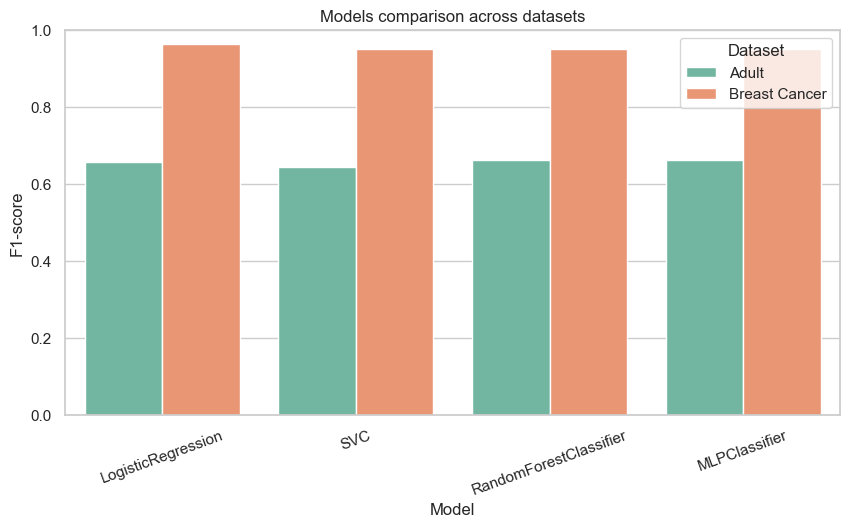

,Dataset,Experiment,Model,Preprocessing,Accuracy,F1-score,ROC-AUC
0,Adult,Models comparison,LogisticRegression,SimpleImputer + StandardScaler + OneHotEncoder,0.8525,0.6568,0.9040
1,Adult,Models comparison,SVC,SimpleImputer + StandardScaler + OneHotEncoder,0.8495,0.6435,0.8987
2,Adult,Models comparison,RandomForestClassifier,SimpleImputer + StandardScaler + OneHotEncoder,0.8505,0.6631,0.8932
3,Adult,Models comparison,MLPClassifier,SimpleImputer + StandardScaler + OneHotEncoder,0.8517,0.6625,0.9004
4,Breast Cancer,Models comparison,LogisticRegression,SimpleImputer + StandardScaler,0.9737,0.9639,0.9960
5,Breast Cancer,Models comparison,SVC,SimpleImputer + StandardScaler,0.9649,0.9500,0.9914
6,Breast Cancer,Models comparison,RandomForestClassifier,SimpleImputer + StandardScaler,0.9649,0.9500,0.9942
7,Breast Cancer,Models comparison,MLPClassifier,SimpleImputer + StandardScaler,0.9649,0.9500,0.9927


In [6]:
models_results = pd.concat([adult_models, bc_models], ignore_index=True)
plt.figure(figsize=(10, 5))
sns.barplot(data=models_results, x="Model", y="F1-score", hue="Dataset", palette="Set2")
plt.ylim(0, 1.0)
plt.title("Models comparison across datasets")
plt.xlabel("Model")
plt.ylabel("F1-score")
plt.xticks(rotation=20)
save_figure(FIGURES_DIR / "cross_dataset_models_comparison.png")
plt.show()
models_results


## Итоговые выводы

На Adult Census основными сложностями были категориальные признаки, пропуски и дисбаланс классов. Поэтому особенно важными оказались корректная обработка категорий, импутация и балансировка классов.

На Breast Cancer все признаки числовые, пропуски отсутствуют, а модели показывают более высокое качество. Для этого датасета масштабирование имеет большее значение, потому что числовые признаки измеряются в разных диапазонах.

Балансировка классов оказалась особенно важной для Adult Census. Импутация является обязательным preprocessing step, но более сложный `KNNImputer` не всегда улучшает качество. Scaling дал ограниченный, но полезный эффект. RandomForest и MLP могут давать лучший F1-score, однако результат зависит от структуры данных. Главный вывод практики: качество моделей зависит не только от выбранного алгоритма, но и от корректно построенного preprocessing pipeline.